# IMPORT LIBRARIES

In [1]:
import torch
from torch import nn
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# --------------------------------------------------------------------------

# IMPORTANT UNDERSTANDING

# Unlike CIFAR10:

# Intel dataset is stored as folders.

#----------------------------------------------------------------------------

# DOWNLOAD DATASET

In [2]:
import kagglehub
path=kagglehub.dataset_download(
  "puneet6060/intel-image-classification"
)
print(path)

C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


# UNDERSTAND DATASET STRUCTURE

In [3]:
os.listdir(path)

# VERY Important

# This dataset is NOT:

# CSV
# tensors
# arrays.

# It is actual image folders.

['seg_pred', 'seg_test', 'seg_train']

# CREATE TRAIN/TEST PATHS

In [4]:
train_path=os.path.join(
  path,
  "seg_train",
  "seg_train"
)

test_path=os.path.join(
  path,
  "seg_test",
  "seg_test"
)

print(train_path)
print(test_path)

C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test


# INSPECT CLASSES

In [5]:
os.listdir(train_path)

# VERY Important Observation

# These folder names automatically become:

# class labels

# inside PyTorch.

# This is how:

# ImageFolder
# custom datasets

# work.

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# CREATE TRANSFORMS

In [6]:
transform=transforms.Compose([
  transforms.Resize((128,128)),
  transforms.ToTensor()
])

# LOAD DATASET USING ImageFolder

In [7]:
train_data=datasets.ImageFolder(
  root=train_path,
  transform=transform
)

test_data=datasets.ImageFolder(
  root=test_path,
  transform=transform
)

In [8]:
train_data

Dataset ImageFolder
    Number of datapoints: 14034
    Root location: C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

# INSPECT CLASS MAPPING

In [9]:
train_data.class_to_idx

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [10]:
test_data.class_to_idx

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

# INSPECT DATASET SIZE

In [11]:
print(len(train_data))
print(len(test_data))

14034
3000


# CHECK ONE SAMPLE

In [12]:
image,label=train_data[0]
print(image.shape)
print(label)

torch.Size([3, 128, 128])
0


# VISUALIZE IMAGE

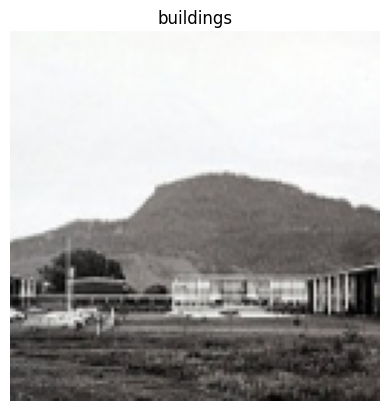

In [13]:
plt.imshow(image.permute(1,2,0))
plt.title(
  train_data.classes[label]
)
plt.axis(False)
plt.show()

# CREATE DATALOADERS

In [14]:
train_dataloader=DataLoader(
  train_data,
  batch_size=32,
  shuffle=True,
  num_workers=2,
  pin_memory=True
)

test_dataloader=DataLoader(
  test_data,
  batch_size=32,
  shuffle=False,
  num_workers=2,
  pin_memory=True
)

# INSPECT ONE BATCH

In [15]:
images,labels=next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


# VISUALIZE BATCH IMAGES

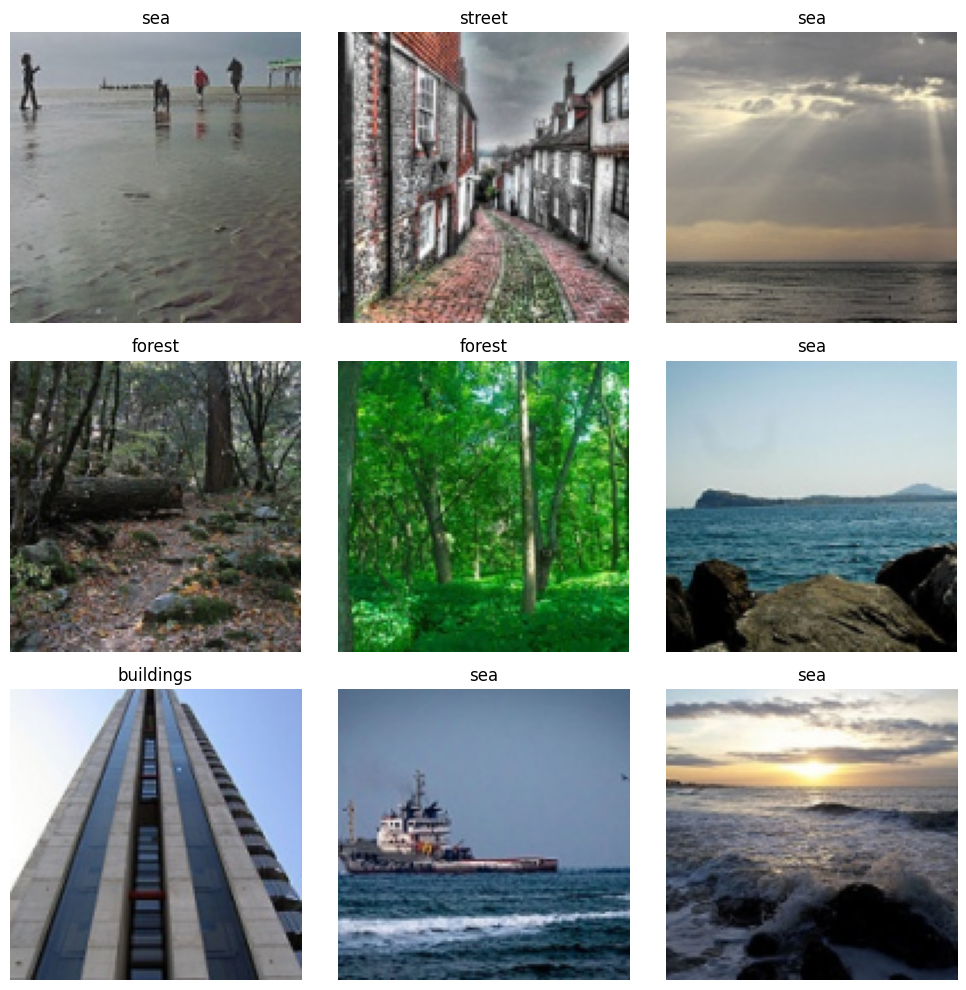

In [16]:
fig=plt.figure(figsize=(10,10))

for i in range(9) : 
  ax=fig.add_subplot(3,3,i+1)
  img=images[i]
  label=labels[i]
  ax.imshow(img.permute(1,2,0))
  
  ax.set_title(
    train_data.classes[label]
  )
  ax.axis(False)
  
plt.tight_layout()
plt.show()

# Now we'll begin with baseline_cnn and this will become our model_0

#### DEVICE SETUP

In [17]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## BUILD BASELINE CNN (model_0)

In [18]:
class TinyVGG(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_block_1=nn.Sequential(
      nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.Conv2d(
        in_channels=32,
        out_channels=32,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    
    self.conv_block_2=nn.Sequential(
      nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.Conv2d(
        in_channels=64,
        out_channels=64,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    
    self.classifier=nn.Sequential(
      nn.Flatten(),
      nn.Linear(
        in_features=64*32*32,
        out_features=len(train_data.classes)
      )
    )
    
  
  def forward(self,x):
    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    
    return x
      

# CREATE model_0

In [19]:
model_0=TinyVGG().to(device)

# Verify Output Shape

In [20]:
X,y=next(iter(train_dataloader))
X=X.to(device)
y=y.to(device)
output=model_0(X)
print(output)
print(output.shape)

tensor([[-1.0416e-02,  9.8401e-03, -1.3143e-02, -8.4440e-03, -1.6895e-02,
          2.8648e-03],
        [-1.7962e-02,  1.2096e-02, -1.3850e-02, -5.7182e-03, -2.1672e-02,
         -1.5530e-03],
        [-1.8930e-02,  1.1349e-02, -1.2857e-02, -3.6076e-03, -2.3148e-02,
          3.1790e-03],
        [-1.5244e-02,  9.5318e-03, -1.4034e-02, -2.8063e-03, -2.4593e-02,
         -3.2956e-04],
        [-1.9087e-02,  8.5510e-03, -1.4591e-02, -5.5151e-03, -2.2848e-02,
          4.2223e-03],
        [-1.2729e-02,  9.9209e-03, -1.5425e-02, -8.3731e-03, -1.8102e-02,
         -6.5139e-04],
        [-1.5160e-02,  9.6004e-03, -1.3024e-02, -6.5728e-03, -2.2191e-02,
         -7.3132e-04],
        [-1.0220e-02,  9.7720e-03, -1.5920e-02, -1.4262e-02, -2.2458e-02,
         -2.3931e-03],
        [-1.3521e-02,  7.7392e-03, -1.5920e-02, -1.0539e-02, -2.4977e-02,
         -3.7568e-03],
        [-1.6625e-02,  6.7251e-03, -1.3497e-02, -1.8512e-03, -2.5373e-02,
          2.0232e-03],
        [-1.1513e-02,  1.1122e

# CREATE TRAIN FUNCTION

In [21]:
def train_step(
  model,
  dataloader,
  loss_fn,
  optimizer,
  device
) : 
  model.train()
  
  train_loss=0
  correct=0
  for X,y in dataloader : 
    X,y=X.to(device) , y.to(device)
    # forward pass
    y_logits=model(X)
    # loss
    loss=loss_fn(y_logits,y)
    train_loss+=loss.item()
    
    # predictions
    y_pred=torch.argmax(y_logits,dim=1)
    correct+=(y_pred==y).sum().item()
    
    # optimizer step
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()
  train_loss/=len(dataloader)
  train_acc=correct/len(dataloader.dataset)
  
  return train_loss , train_acc
    
    
    
    # Returns:

# train_loss
# train_acc

# for ONE epoch.
    

# CREATE TEST FUNCTION

In [22]:
def test_step(
  model,
  dataloader,
  loss_fn,
  device
) : 
  model.eval()
  test_loss=0
  correct=0
  
  with torch.inference_mode() : 
    for X,y in dataloader : 
      X,y=X.to(device) , y.to(device)
      test_logits=model(X)
      loss=loss_fn(test_logits,y)
      test_loss+=loss.item()
      
      y_pred=torch.argmax(test_logits,dim=1)
      correct+=(y_pred==y).sum().item()
    
  test_loss/=len(dataloader)
  test_acc=correct/len(dataloader.dataset)
  
  return test_loss , test_acc

# CREATE EXPERIMENT RESULTS DICTIONARY

In [23]:
results={}

# SETUP model_0

In [24]:
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(
  model_0.parameters(),
  lr=0.001
)

# CREATE TRAINING TRACKERS

In [25]:
model_0_results={
  "train_loss":[],
  "train_acc":[],
  "test_loss":[],
  "test_acc":[]
}

# TRAIN model_0

In [26]:
epochs=5

for epoch in range(epochs):
  train_loss , train_acc= train_step(
    model=model_0,
    dataloader=train_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
  )
  
  test_loss , test_acc=test_step(
    model=model_0,
    dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device
  )
  
  # store results
  model_0_results["train_loss"].append(train_loss)
  model_0_results["train_acc"].append(train_acc)
  model_0_results["test_loss"].append(test_loss)
  model_0_results["test_acc"].append(test_acc)
  
  print(f"Epoch: {epoch+1}")

  print(f"Train Loss: {train_loss:.4f}")

  print(f"Train Accuracy: {train_acc*100:.2f}%")

  print(f"Test Loss: {test_loss:.4f}")

  print(f"Test Accuracy: {test_acc*100:.2f}%\n")

Epoch: 1
Train Loss: 1.0319
Train Accuracy: 59.64%
Test Loss: 0.8411
Test Accuracy: 68.00%

Epoch: 2
Train Loss: 0.7118
Train Accuracy: 73.67%
Test Loss: 0.6706
Test Accuracy: 74.57%

Epoch: 3
Train Loss: 0.5495
Train Accuracy: 79.98%
Test Loss: 0.5777
Test Accuracy: 79.97%

Epoch: 4
Train Loss: 0.4194
Train Accuracy: 84.79%
Test Loss: 0.6509
Test Accuracy: 77.57%

Epoch: 5
Train Loss: 0.3001
Train Accuracy: 89.28%
Test Loss: 0.7263
Test Accuracy: 76.10%



# PLOT LOSS CURVES

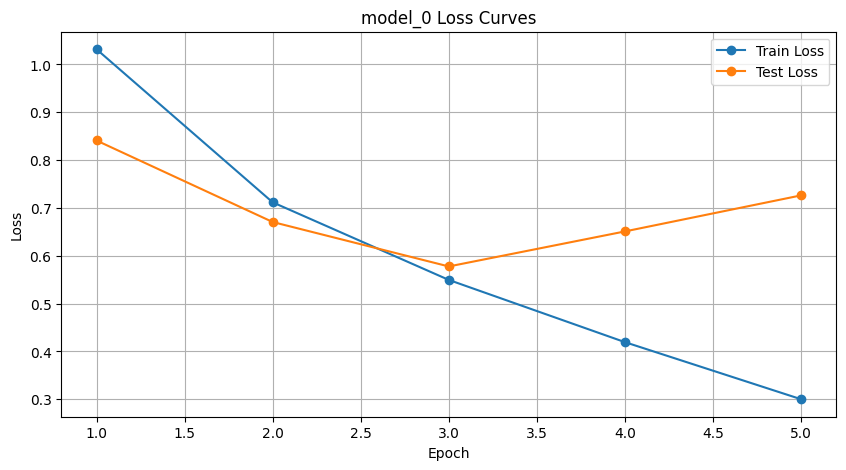

In [27]:
import matplotlib.pyplot as plt
epochs_range=range(1,epochs+1)

plt.figure(figsize=(10,5))

plt.plot(
  epochs_range,
  model_0_results["train_loss"],
  marker='o',
  label="Train Loss"
)

plt.plot(
    epochs_range,
    model_0_results["test_loss"],
    marker='o',
    label="Test Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("model_0 Loss Curves")

plt.legend()

plt.grid(True)

plt.show()


# PLOT ACCURACY CURVES

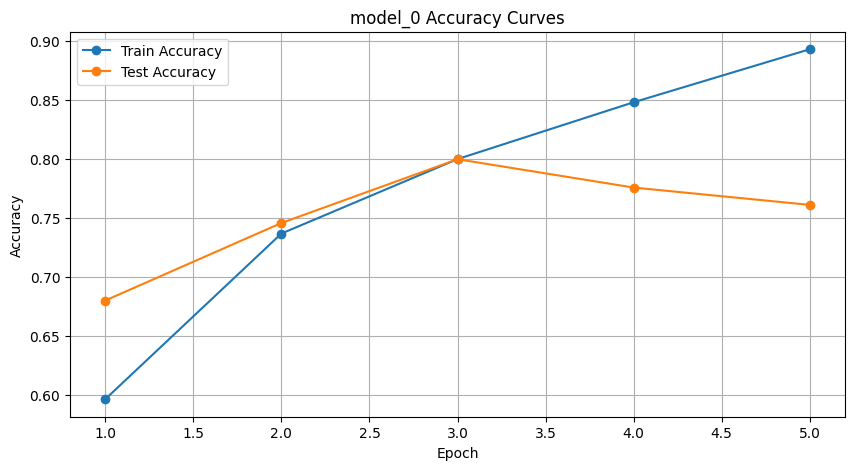

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    model_0_results["train_acc"],
    marker='o',
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    model_0_results["test_acc"],
    marker='o',
    label="Test Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("model_0 Accuracy Curves")

plt.legend()

plt.grid(True)

plt.show()

# STORE RESULTS GLOBALLY

In [29]:
results["model_0"] = model_0_results

# CREATE QUICK SUMMARY TABLE

In [30]:
import pandas as pd

summary_df = pd.DataFrame({

    "Model": ["model_0"],

    "Final Train Accuracy": [
        model_0_results["train_acc"][-1] * 100
    ],

    "Final Test Accuracy": [
        model_0_results["test_acc"][-1] * 100
    ]

})

summary_df

,Model,Final Train Accuracy,Final Test Accuracy
0,model_0,89.283169,76.1


In [31]:
print(len(train_data))
print(len(test_data))

14034
3000


# IMPORT RESNET18

In [32]:
from torchvision.models import (
  resnet18,
  ResNet18_Weights
)

# LOAD PRETRAINED MODEL

In [33]:
model_1=resnet18(
  weights=ResNet18_Weights.DEFAULT
)

## INSPECT FINAL LAYER

In [34]:
print(model_1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
print(model_1.fc)

Linear(in_features=512, out_features=1000, bias=True)


# REPLACE FINAL CLASSIFIER

In [36]:
model_1.fc=nn.Linear(
  in_features=512,
  out_features=len(train_data.classes)
)

# We are:

# keeping pretrained feature extractor
# replacing task-specific classifier.

# This is the CORE of transfer learning.

# FREEZE PRETRAINED LAYERS

In [37]:
for param in model_1.parameters():
  param.requires_grad=False
  
  
  # WHAT DOES THIS DO?

# Prevents:

# pretrained weights from changing.

# Meaning:

# ResNet visual knowledge preserved.


# But this ALSO froze:

# final FC layer.

# So now we re-enable it.

# UNFREEZE CLASSIFIER

In [38]:
for param in model_1.fc.parameters():
  param.requires_grad=True

# MOVE TO GPU

In [39]:
model_1=model_1.to(device)

# CREATE LOSS + OPTIMIZER

In [40]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(
  model_1.fc.parameters(),
  lr=0.001
)

# CREATE RESULTS TRACKER

In [41]:
model_1_results = {

    "train_loss": [],

    "train_acc": [],

    "test_loss": [],

    "test_acc": []

}

# TRAIN model_1

In [42]:
epochs = 5

for epoch in range(epochs):

    train_loss, train_acc = train_step(

        model=model_1,

        dataloader=train_dataloader,

        loss_fn=loss_fn,

        optimizer=optimizer,

        device=device
    )

    test_loss, test_acc = test_step(

        model=model_1,

        dataloader=test_dataloader,

        loss_fn=loss_fn,

        device=device
    )

    # STORE RESULTS
    model_1_results["train_loss"].append(train_loss)

    model_1_results["train_acc"].append(train_acc)

    model_1_results["test_loss"].append(test_loss)

    model_1_results["test_acc"].append(test_acc)

    print(f"Epoch: {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc*100:.2f}%")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Test Accuracy: {test_acc*100:.2f}%\n")

Epoch: 1
Train Loss: 0.5879
Train Accuracy: 79.76%
Test Loss: 0.3776
Test Accuracy: 87.10%

Epoch: 2
Train Loss: 0.4039
Train Accuracy: 85.64%
Test Loss: 0.3787
Test Accuracy: 86.60%

Epoch: 3
Train Loss: 0.3736
Train Accuracy: 86.69%
Test Loss: 0.3491
Test Accuracy: 87.53%

Epoch: 4
Train Loss: 0.3659
Train Accuracy: 86.73%
Test Loss: 0.3467
Test Accuracy: 88.00%

Epoch: 5
Train Loss: 0.3555
Train Accuracy: 87.14%
Test Loss: 0.3438
Test Accuracy: 87.93%



# STORE model_1 RESULTS

In [43]:
results["model_1"]=model_1_results

# PLOT model_1 LOSS CURVES

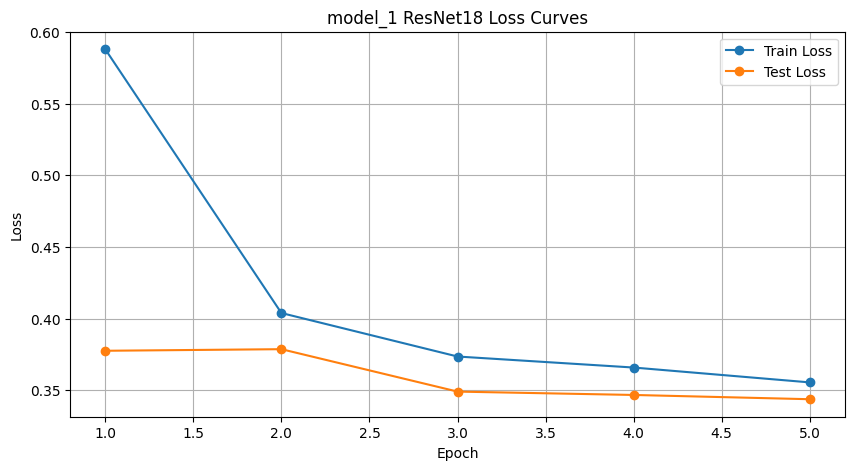

In [44]:
epochs_range = range(1, epochs+1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    model_1_results["train_loss"],
    marker='o',
    label="Train Loss"
)

plt.plot(
    epochs_range,
    model_1_results["test_loss"],
    marker='o',
    label="Test Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("model_1 ResNet18 Loss Curves")

plt.legend()

plt.grid(True)

plt.show()

# PLOT model_1 ACCURACY CURVES

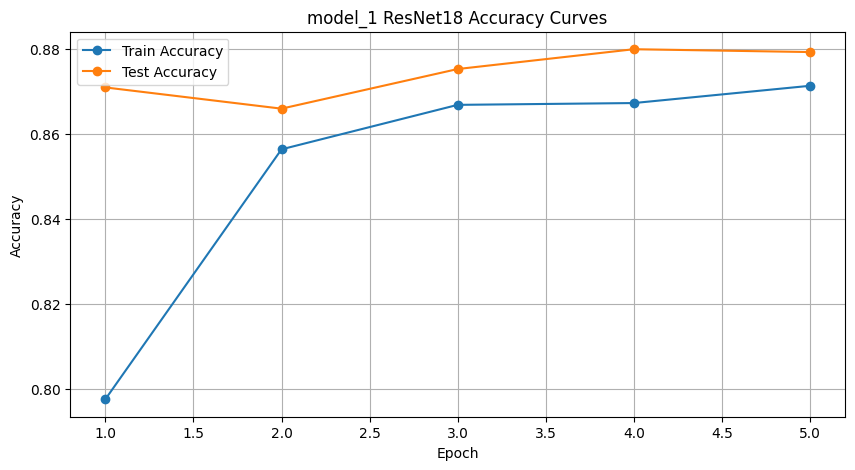

In [45]:
plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    model_1_results["train_acc"],
    marker='o',
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    model_1_results["test_acc"],
    marker='o',
    label="Test Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("model_1 ResNet18 Accuracy Curves")

plt.legend()

plt.grid(True)

plt.show()

# CREATE COMPARISON TABLE


In [46]:
comparison_df = pd.DataFrame({

    "Model": [

        "model_0 CNN",

        "model_1 ResNet18"

    ],

    "Final Train Accuracy": [

        model_0_results["train_acc"][-1] * 100,

        model_1_results["train_acc"][-1] * 100
    ],

    "Final Test Accuracy": [

        model_0_results["test_acc"][-1] * 100,

        model_1_results["test_acc"][-1] * 100
    ]

})

comparison_df

,Model,Final Train Accuracy,Final Test Accuracy
0,model_0 CNN,89.283169,76.100000
1,model_1 ResNet18,87.138378,87.933333


# ACCURACY BAR PLOT

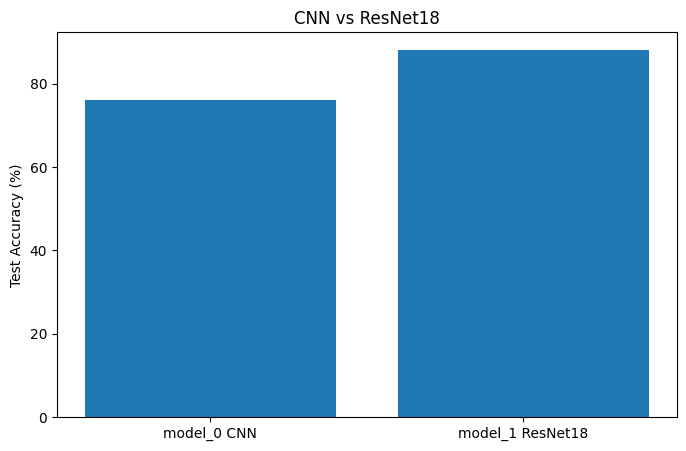

In [47]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison_df["Model"],

    comparison_df["Final Test Accuracy"]

)

plt.ylabel("Test Accuracy (%)")

plt.title("CNN vs ResNet18")

plt.show()

# FINE TUNING---->

This is where:

pretrained features themselves adapt
to your dataset.

This is a major deep learning concept.

## CREATE model_2

In [48]:
model_2=resnet18(
  weights=ResNet18_Weights.DEFAULT
)

## REPLACE FINAL LAYER

In [49]:
model_2.fc=nn.Linear(
  in_features=512,
  out_features=len(train_data.classes)
)

## FREEZE EVERYTHING FIRST

In [50]:
for param in model_2.parameters() : 
  param.requires_grad=False

# UNFREEZE LAYER4

In [51]:
for param in model_2.layer4.parameters() : 
  param.requires_grad=True

# UNFREEZE CLASSIFIER

In [52]:
for param in model_2.fc.parameters() : 
  param.requires_grad=True
  
  
  # NOW TRAINABLE

# Only:

# layer4
# fc

# Everything else:

# frozen pretrained backbone.

## MOVE TO GPU

In [53]:
model_2=model_2.to(device)

# IMPORTANT OPTIMIZER CHANGE

In [54]:
optimizer=torch.optim.Adam(
  filter(
    lambda p: p.requires_grad,
    model_2.parameters()
  ),
  lr=0.0001
  
)

# -------------------------------------------------------------------------

# WHY LOWER LR?

# Because pretrained weights:

# already valuable.

# Large LR may:

# destroy pretrained features.

# Fine-tuning usually needs:

# careful small updates.

# ----------------------------------------------------------------------------

# CREATE RESULTS TRACKER

In [55]:
model_2_results = {

    "train_loss": [],

    "train_acc": [],

    "test_loss": [],

    "test_acc": []

}

# TRAIN model_2

In [56]:
epochs = 5

for epoch in range(epochs):

    train_loss, train_acc = train_step(

        model=model_2,

        dataloader=train_dataloader,

        loss_fn=loss_fn,

        optimizer=optimizer,

        device=device
    )

    test_loss, test_acc = test_step(

        model=model_2,

        dataloader=test_dataloader,

        loss_fn=loss_fn,

        device=device
    )

    model_2_results["train_loss"].append(train_loss)

    model_2_results["train_acc"].append(train_acc)

    model_2_results["test_loss"].append(test_loss)

    model_2_results["test_acc"].append(test_acc)

    print(f"Epoch: {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc*100:.2f}%")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Test Accuracy: {test_acc*100:.2f}%\n")

Epoch: 1
Train Loss: 0.3380
Train Accuracy: 88.19%
Test Loss: 0.2207
Test Accuracy: 92.13%

Epoch: 2
Train Loss: 0.1287
Train Accuracy: 95.48%
Test Loss: 0.2442
Test Accuracy: 91.93%

Epoch: 3
Train Loss: 0.0592
Train Accuracy: 98.10%
Test Loss: 0.2585
Test Accuracy: 92.43%

Epoch: 4
Train Loss: 0.0369
Train Accuracy: 99.04%
Test Loss: 0.2652
Test Accuracy: 92.60%

Epoch: 5
Train Loss: 0.0238
Train Accuracy: 99.29%
Test Loss: 0.3068
Test Accuracy: 92.37%



# STORE model_2

In [57]:
results["model_2"] = model_2_results

## CREATE FINAL COMPARISON TABLE

In [58]:
comparison_df = pd.DataFrame({

    "Model": [

        "model_0 CNN",

        "model_1 ResNet18",

        "model_2 FineTuned ResNet18"
    ],

    "Final Train Accuracy": [

        model_0_results["train_acc"][-1] * 100,

        model_1_results["train_acc"][-1] * 100,

        model_2_results["train_acc"][-1] * 100
    ],

    "Final Test Accuracy": [

        model_0_results["test_acc"][-1] * 100,

        model_1_results["test_acc"][-1] * 100,

        model_2_results["test_acc"][-1] * 100
    ]

})

comparison_df

,Model,Final Train Accuracy,Final Test Accuracy
0,model_0 CNN,89.283169,76.100000
1,model_1 ResNet18,87.138378,87.933333
2,model_2 FineTuned ResNet18,99.287445,92.366667


## BAR PLOT COMPARISON

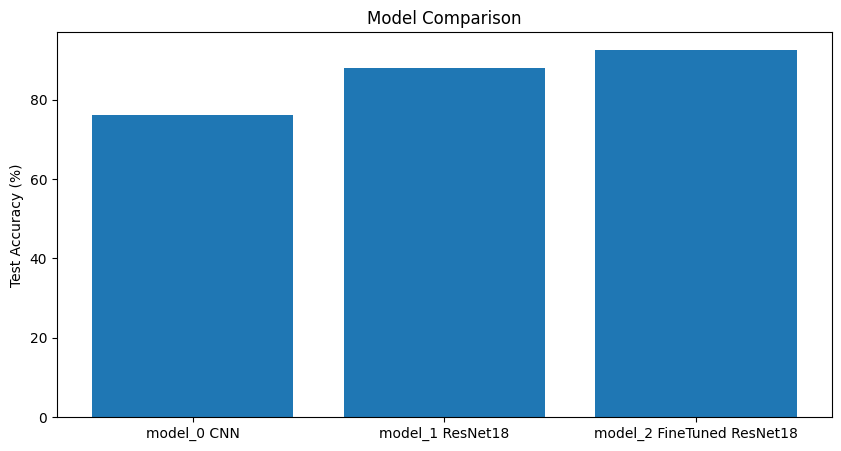

In [59]:
plt.figure(figsize=(10,5))

plt.bar(

    comparison_df["Model"],

    comparison_df["Final Test Accuracy"]

)

plt.ylabel("Test Accuracy (%)")

plt.title("Model Comparison")

plt.show()

## SIDE-BY-SIDE LOSS CURVES

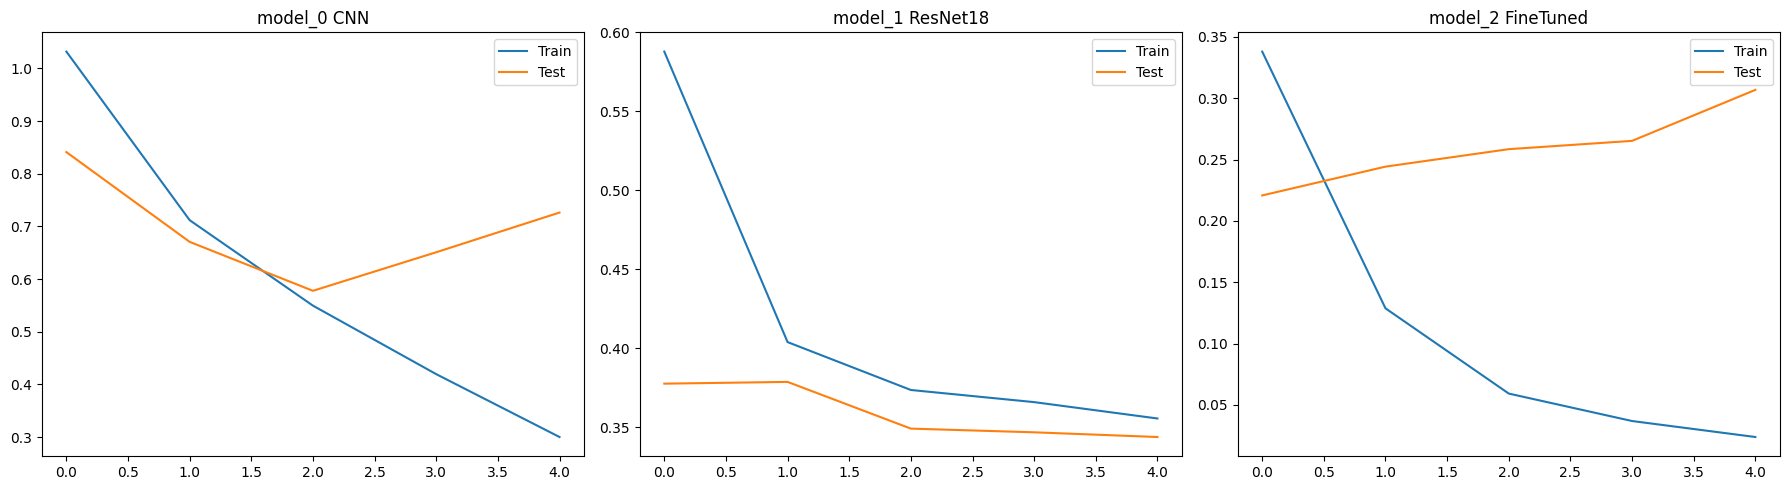

In [60]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# model_0
axes[0].plot(
    model_0_results["train_loss"],
    label="Train"
)

axes[0].plot(
    model_0_results["test_loss"],
    label="Test"
)

axes[0].set_title("model_0 CNN")

axes[0].legend()

# model_1
axes[1].plot(
    model_1_results["train_loss"],
    label="Train"
)

axes[1].plot(
    model_1_results["test_loss"],
    label="Test"
)

axes[1].set_title("model_1 ResNet18")

axes[1].legend()

# model_2
axes[2].plot(
    model_2_results["train_loss"],
    label="Train"
)

axes[2].plot(
    model_2_results["test_loss"],
    label="Test"
)

axes[2].set_title("model_2 FineTuned")

axes[2].legend()

plt.tight_layout()

plt.show()

# EFFICIENT NET

PROBLEM BEFORE EFFICIENTNET

Researchers kept improving CNNs by randomly increasing:

depth
width
image resolution
DEPTH

More layers.

Example:

18 layers → 50 layers → 101 layers

Used by:

ResNet.
WIDTH

More channels/filters.

Example:

64 channels → 128 → 256
RESOLUTION

Larger input images.

Example:

128×128 → 224×224 → 512×512

### EFFICIENTNET'S BIG IDEA

Instead of scaling randomly:

scale EVERYTHING systematically

Meaning:

depth
width
resolution

increase together in balanced way.

# This process was called as Compound Scaling and this is the core idea of EFFNet

## IMPORTANT ARCHITECTURE DIFFERENCE

EfficientNet is STILL fundamentally a CNN.

It still uses:

convolutions
activations
pooling-like operations.

So your CNN intuition still applies.

BUT It Introduces Better Building Blocks

EfficientNet heavily uses:

MBConv Blocks

### WHAT IS MBConv?

Originally from:

MobileNet.

Designed for:

efficient computation.

#### Its unique structure processes data in three sequential stages to save computing power:Expansion Phase: A \(1 \times 1\) convolution expands the number of input channels (making the data representation "wider") to allow the network to extract more complex features.

#### Depthwise Convolution: A spatial filter is applied to each channel individually, dramatically reducing the number of required mathematical operations while still capturing spatial patterns.

#### Projection Phase: Another \(1 \times 1\) convolution compresses the channels back down, acting as a linear bottleneck that preserves information without the need for additional non-linear activation functions.




#### DEPTHWISE SEPARABLE CONVOLUTION

Breaks operation into TWO smaller steps:

STEP 1 — Depthwise Conv

Each channel processed separately.

STEP 2 — Pointwise Conv

Channels mixed using:

1×1 convolutions
RESULT

Much fewer computations.

Mobile Inverted Bottleneck Convolution

Originally from:
MobileNetV2

EfficientNet heavily uses these blocks.

First Understand Normal CNN Block

Traditional CNN:

Input
 ↓
3x3 Conv
 ↓
ReLU
 ↓
Output

Problem:

expensive computation
EfficientNet Uses Smarter Block

Instead of directly doing heavy convolution:

Narrow → Expand → Process → Compress

This saves computation.

MBConv Detailed

Suppose input:

32 channels
Step 1 — Expansion Layer

Expand channels:

32 → 192

using:

1x1 Conv

Why?

richer feature space
Step 2 — Depthwise Convolution

Instead of normal convolution:

Normal convolution:

every filter sees ALL channels

Very expensive.

Depthwise convolution:

one filter per channel

Much cheaper.

Example:

192 channels
→ apply 192 separate filters

Huge computation reduction.

Visual Intuition

Normal Conv:

All channels mixed together

Depthwise Conv:

Each channel processed independently
Step 3 — Squeeze-and-Excitation (SE Block)

EfficientNet asks:

Which channels are important?

Some channels detect:

edges
eyes
textures
wheels

Not all equally useful.

SE Block learns:

which channels to emphasize
which to suppress
Analogy

Suppose:

192 students speaking
teacher listens more to best students

SE block gives attention weights.

Step 4 — Projection Layer

Compress back:

192 → 32

using:

1x1 Conv
Step 5 — Residual Connection

If shapes match:

Input + Output

like ResNet.

Helps:

gradient flow
stable training
Full MBConv Flow
Input
 ↓
1x1 Expand Conv
 ↓
Depthwise Conv
 ↓
SE Attention
 ↓
1x1 Projection Conv
 ↓
Residual Add
 ↓
Output

This is the core of EfficientNet.

Why EfficientNet Is Powerful

Because it combines:

Technique	Purpose
Depthwise Conv	reduce computation
SE Block	attention mechanism
Residual Connection	stable gradients
Compound Scaling	efficient scaling
Why It Became Famous

Before EfficientNet:

models got huge
expensive GPUs needed

EfficientNet achieved:

better accuracy
fewer parameters
less FLOPs

# EFFICIENT NET-B0

### IMPORT EFFICIENTNET

In [61]:
from torchvision.models import (
  efficientnet_b0,
  EfficientNet_B0_Weights
)

## LOAD PRETRAINED EFFICIENTNET

In [62]:
model_3=efficientnet_b0(
  weights=EfficientNet_B0_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ahlaw/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 11.7MB/s]


In [63]:
print(model_3)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# INSPECT CLASSIFIER

In [65]:
print(model_3.classifier)

# -----------------------------------------------------------------------

# WHY DROPOUT?

# EfficientNet includes:

# regularization
# internally.

# This helps:

# reduce overfitting.

# ---------------------------------------------------------------------------

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


# REPLACE FINAL CLASSIFIER

In [66]:
model_3.classifier=nn.Sequential(
  nn.Dropout(p=0.2),
  nn.Linear(
    in_features=1280,
    out_features=len(train_data.classes)
  )
)

## FREEZE PRETRAINED LAYERS

In [67]:
for param in model_3.parameters() : 
  param.requires_grad=False

## UNFREEZE CLASSIFIER

In [68]:
for param in model_3.classifier.parameters():

    param.requires_grad = True

## MOVE TO GPU

In [69]:
model_3=model_3.to(device)

## LOSS + OPTIMIZER

In [70]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model_3.classifier.parameters(),

    lr=0.001
)

## CREATE RESULTS TRACKER

In [71]:
model_3_results = {

    "train_loss": [],

    "train_acc": [],

    "test_loss": [],

    "test_acc": []

}


# TRAIN model_3

In [72]:
epochs = 5

for epoch in range(epochs):

    train_loss, train_acc = train_step(

        model=model_3,

        dataloader=train_dataloader,

        loss_fn=loss_fn,

        optimizer=optimizer,

        device=device
    )

    test_loss, test_acc = test_step(

        model=model_3,

        dataloader=test_dataloader,

        loss_fn=loss_fn,

        device=device
    )

    model_3_results["train_loss"].append(train_loss)

    model_3_results["train_acc"].append(train_acc)

    model_3_results["test_loss"].append(test_loss)

    model_3_results["test_acc"].append(test_acc)

    print(f"Epoch: {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc*100:.2f}%")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Test Accuracy: {test_acc*100:.2f}%\n")

Epoch: 1
Train Loss: 0.6500
Train Accuracy: 78.45%
Test Loss: 0.4615
Test Accuracy: 83.67%

Epoch: 2
Train Loss: 0.4729
Train Accuracy: 82.84%
Test Loss: 0.4166
Test Accuracy: 85.00%

Epoch: 3
Train Loss: 0.4457
Train Accuracy: 83.74%
Test Loss: 0.4135
Test Accuracy: 84.67%

Epoch: 4
Train Loss: 0.4309
Train Accuracy: 84.00%
Test Loss: 0.4137
Test Accuracy: 84.63%

Epoch: 5
Train Loss: 0.4319
Train Accuracy: 84.08%
Test Loss: 0.4021
Test Accuracy: 85.53%



## STORE model_3

In [73]:
results["model_3"] = model_3_results

## FINAL COMPARISON TABLE

In [74]:
comparison_df = pd.DataFrame({

    "Model": [

        "model_0 CNN",

        "model_1 ResNet18",

        "model_2 FineTuned ResNet18",

        "model_3 EfficientNet-B0"
    ],

    "Final Train Accuracy": [

        model_0_results["train_acc"][-1] * 100,

        model_1_results["train_acc"][-1] * 100,

        model_2_results["train_acc"][-1] * 100,

        model_3_results["train_acc"][-1] * 100
    ],

    "Final Test Accuracy": [

        model_0_results["test_acc"][-1] * 100,

        model_1_results["test_acc"][-1] * 100,

        model_2_results["test_acc"][-1] * 100,

        model_3_results["test_acc"][-1] * 100
    ]

})

comparison_df

,Model,Final Train Accuracy,Final Test Accuracy
0,model_0 CNN,89.283169,76.100000
1,model_1 ResNet18,87.138378,87.933333
2,model_2 FineTuned ResNet18,99.287445,92.366667
3,model_3 EfficientNet-B0,84.081516,85.533333


### FINAL ACCURACY COMPARISON PLOT

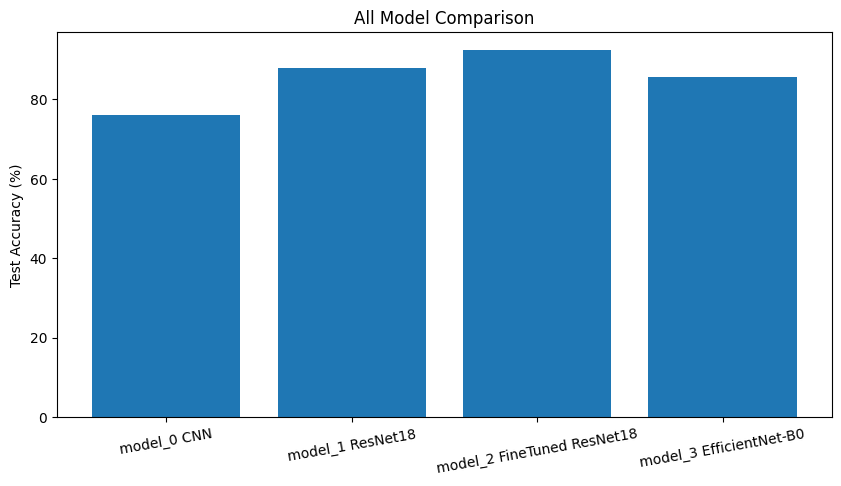

In [75]:
plt.figure(figsize=(10,5))

plt.bar(

    comparison_df["Model"],

    comparison_df["Final Test Accuracy"]

)

plt.ylabel("Test Accuracy (%)")

plt.title("All Model Comparison")

plt.xticks(rotation=10)

plt.show()

## SIDE-BY-SIDE LOSS CURVES

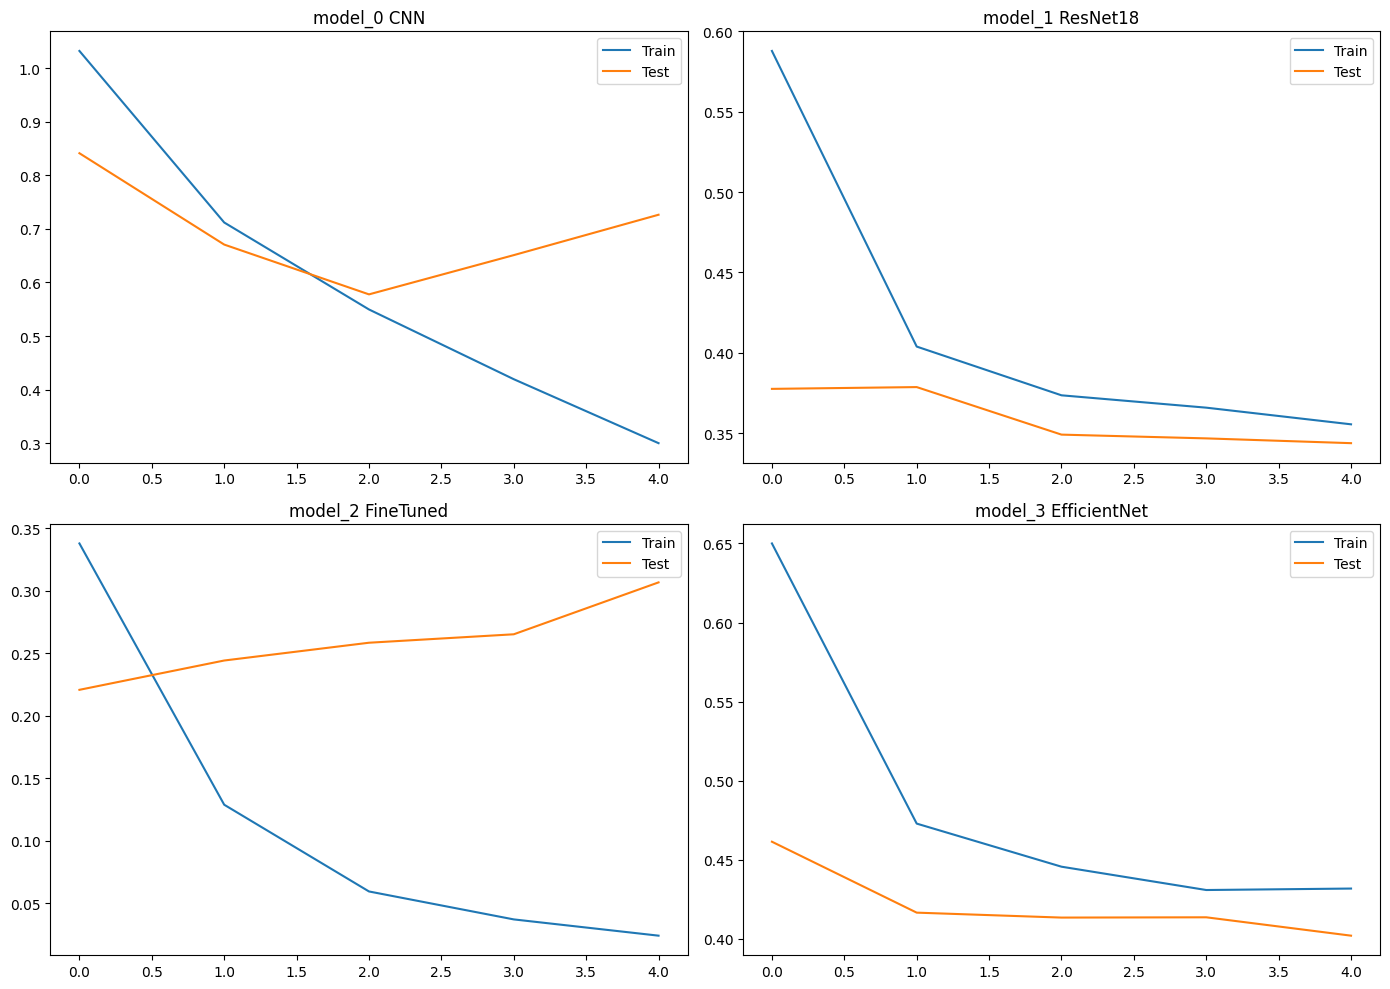

In [76]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

# model_0
axes[0,0].plot(
    model_0_results["train_loss"],
    label="Train"
)

axes[0,0].plot(
    model_0_results["test_loss"],
    label="Test"
)

axes[0,0].set_title("model_0 CNN")

axes[0,0].legend()

# model_1
axes[0,1].plot(
    model_1_results["train_loss"],
    label="Train"
)

axes[0,1].plot(
    model_1_results["test_loss"],
    label="Test"
)

axes[0,1].set_title("model_1 ResNet18")

axes[0,1].legend()

# model_2
axes[1,0].plot(
    model_2_results["train_loss"],
    label="Train"
)

axes[1,0].plot(
    model_2_results["test_loss"],
    label="Test"
)

axes[1,0].set_title("model_2 FineTuned")

axes[1,0].legend()

# model_3
axes[1,1].plot(
    model_3_results["train_loss"],
    label="Train"
)

axes[1,1].plot(
    model_3_results["test_loss"],
    label="Test"
)

axes[1,1].set_title("model_3 EfficientNet")

axes[1,1].legend()

plt.tight_layout()

plt.show()